# 🌳 Yggdrasil — Segmentação de PD (classificação)

Tutorial do subpacote `yggdrasil.credit_risk.pd`. Constrói uma régua de **PD** (Probability of Default) a partir de uma base sintética com **alvo binário** (0 = adimplente, 1 = default), mostra as folhas, a **discriminação** (KS, AUC, Gini, Acurácia, F1), as curvas **ROC/KS**, a árvore, o `predict` e a régua em PySpark.

É o gêmeo de classificação do [`04_tutorial_lgd_segmenter`](04_tutorial_lgd_segmenter.ipynb). Tutorial em Markdown: [`docs/credit-risk/pd-segmenter.md`](../../docs/credit-risk/pd-segmenter.md).

**Instalação** (na raiz do repositório):
```bash
pip install -e ".[ui]"   # núcleo + interface interativa
```
> No Databricks: `%pip install -e ".[ui]"` (ou `%pip install optbinning`) num cluster interativo DBR 13.0+ LTS.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
from IPython.display import display
from yggdrasil.credit_risk.pd import SequentialPDSegmenter

# --- base sintética: PD de crédito ao consumidor, com DES, OOT e ESTABILIDADE ---
# A população de COMPROMETIMENTO DE RENDA migra ao longo das safras (dt_ref) — é o que
# faz o PSI subir nas safras recentes (OOT/ESTABILIDADE). O score de bureau tem faltantes.
rng = np.random.default_rng(42)
GAR = {'alienacao': -0.55, 'aval': 0.15, 'fianca': 0.45, 'sem garantia': 1.05}

def gera(n, t0='2022-01-01'):
    dt_ref = pd.to_datetime(t0) + pd.to_timedelta(rng.integers(0, 365, n), unit='D')
    midx = (dt_ref.year.values - 2022) * 12 + (dt_ref.month.values - 1)  # nº do mês desde jan/2022
    comp = rng.beta(2.5, 3, n) * 0.8 + 0.1 + 0.004 * midx                # comprometimento migra ~0,4 p.p./mês
    score = np.clip(rng.normal(640, 95, n), 300, 900)
    score[rng.random(n) < 0.06] = np.nan                                 # ~6% de score faltante
    relac = rng.integers(0, 120, n)
    gar = rng.choice(list(GAR), n, p=[0.50, 0.22, 0.18, 0.10]).astype(object)
    lin = (-2.15 + 2.6 * (comp - 0.4) - 0.0045 * (np.nan_to_num(score, nan=640) - 640)
           - 0.004 * relac + np.array([GAR[g] for g in gar]))
    p = 1 / (1 + np.exp(-lin))
    target = (rng.uniform(0, 1, n) < p).astype(float)                    # alvo BINÁRIO 0/1
    return pd.DataFrame({'comprometimento_renda': comp, 'score_bureau': score,
                         'meses_relacionamento': relac, 'tipo_garantia': gar,
                         'dt_ref': dt_ref, 'target': target})

des = gera(6000, t0='2022-01-01'); des['amostra'] = 'DES'           # desenvolvimento (referência PSI)
oot = gera(2500, t0='2023-07-01'); oot['amostra'] = 'OOT'           # out-of-time (com default realizado)
# ESTABILIDADE: público mais recente, só para validar — SEM variável resposta (target = NaN).
est = gera(1800, t0='2024-01-01'); est['amostra'] = 'ESTABILIDADE'; est['target'] = np.nan

df = pd.concat([des, oot, est], ignore_index=True)
# taxa de default por amostra: ESTABILIDADE fica NaN (sem target), mas com volumetria
df.groupby('amostra', sort=False)['target'].agg(n='size', taxa_default='mean').round(4)

,n,taxa_default
amostra,,
DES,6000,0.1182
OOT,2500,0.1480
ESTABILIDADE,1800,NaN


## Taxa de default ao longo do tempo (safra `dt_ref`)
Análise temporal: **taxa de default por mês de referência**. DES (2022) e OOT (2023–24) têm default realizado; **ESTABILIDADE** (público recente) ainda **não tem target**, então não entra nesta curva — aparece só no PSI. Como o comprometimento de renda migra ao longo das safras, a taxa de default realizada sobe no tempo.

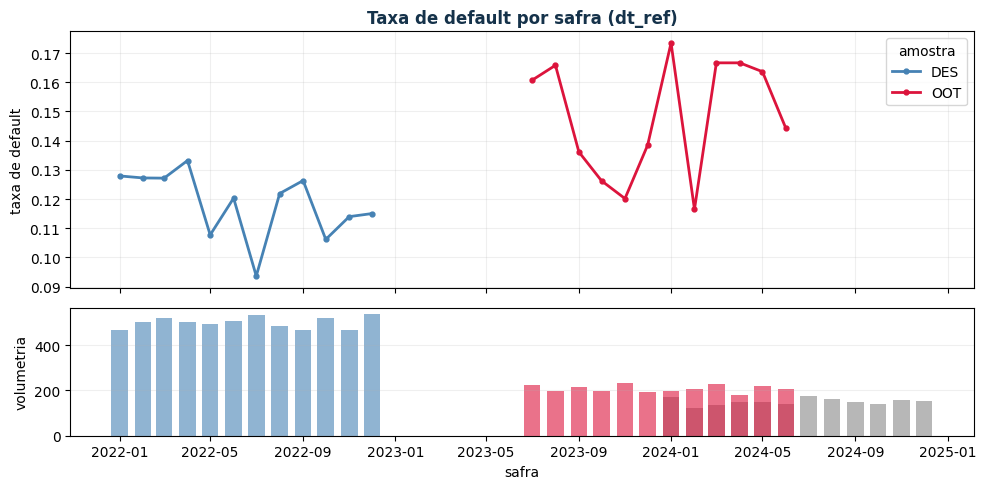

amostra,DES,ESTABILIDADE,OOT
ano,,,
2022,0.118,NaN,NaN
2023,NaN,NaN,0.141
2024,NaN,NaN,0.155


In [2]:
import matplotlib.pyplot as plt

serie = (df.assign(safra=df['dt_ref'].dt.to_period('M').dt.to_timestamp())
           .groupby(['safra', 'amostra'], observed=True)
           .agg(taxa=('target', 'mean'), n=('target', 'size'))
           .reset_index())

cores = {'DES': 'steelblue', 'OOT': 'crimson', 'ESTABILIDADE': '#888888'}
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True,
                               gridspec_kw={'height_ratios': [2, 1]})
for am, g in serie.groupby('amostra', observed=True):
    if g['taxa'].notna().any():                      # ESTABILIDADE não tem default realizado
        ax1.plot(g['safra'], g['taxa'], marker='o', ms=3.5, lw=2,
                 color=cores.get(am), label=am)
    ax2.bar(g['safra'], g['n'], width=22, color=cores.get(am), alpha=0.6, label=am)
ax1.set_title('Taxa de default por safra (dt_ref)', fontweight='bold', color='#15324a')
ax1.set_ylabel('taxa de default'); ax1.grid(alpha=0.2); ax1.legend(title='amostra')
ax2.set_ylabel('volumetria'); ax2.set_xlabel('safra'); ax2.grid(axis='y', alpha=0.2)
fig.tight_layout(); plt.show()

(df.assign(ano=df['dt_ref'].dt.year)
   .pivot_table(index='ano', columns='amostra', values='target', observed=True, dropna=False)
   .round(3))

## Instanciar e construir a árvore automática
O `target` é a coluna **binária**. O `fit_auto` cresce a árvore escolhendo, em cada folha, a variável de maior **IV (WoE binário)**.

In [3]:
seg = SequentialPDSegmenter(
    df, target='target', sample_col='amostra', ref_sample='DES',
    date_col='dt_ref',     # coluna de safra: FORA da modelagem, só p/ análises no tempo
    feature_labels={'comprometimento_renda': 'comprometimento de renda',
                    'score_bureau': 'score de bureau',
                    'meses_relacionamento': 'meses de relacionamento',
                    'tipo_garantia': 'garantia'},
)
seg.fit_auto(max_depth=3, min_iv=0.02)
seg.suggest_split('root')['msg']

[init] amostras: ['DES', 'OOT', 'ESTABILIDADE'] | referência PSI = DES


[fit_auto] árvore gulosa construída: profundidade 3 (máx +3), IV mínimo 0.02 → 12 folhas


"dividir por 'tipo_garantia' (IV=0.2772, médio)"

## Folhas finais (nota, PD, representatividade e PSI)
A `nota_pd` numera as folhas por taxa de default (1 = menor PD). As colunas `pd_DES`/`pd_OOT` mostram a PD por amostra; `psi_OOT` é a contribuição de cada folha à estabilidade.

In [4]:
seg.leaves(with_psi=True)

,segmento,nota_pd,descricao,profundidade,n,repr_%,pd_medio,pd_std,pd_DES,pd_OOT,pd_ESTABILIDADE,psi_OOT,psi_ESTABILIDADE
0,"tipo_garantia: {aval, fianca, sem garantia} | ...",1,garantia em {aval ou fianca ou sem garantia} e...,3,52,0.5,0.0250,0.1474,0.0250,0.0000,NaN,0.0044,0.0023
1,tipo_garantia: {alienacao} | comprometimento_r...,2,garantia em {alienacao} e comprometimento de r...,3,1817,17.6,0.0357,0.1940,0.0357,0.0510,NaN,0.0239,0.0349
2,"tipo_garantia: {aval, fianca, sem garantia} | ...",3,garantia em {aval ou fianca ou sem garantia} e...,3,446,4.3,0.0359,0.2100,0.0359,0.0897,NaN,0.0142,0.0397
3,tipo_garantia: {alienacao} | comprometimento_r...,4,garantia em {alienacao} e comprometimento de r...,3,121,1.2,0.0482,0.1915,0.0482,0.0000,NaN,0.0019,0.0028
4,tipo_garantia: {alienacao} | comprometimento_r...,5,garantia em {alienacao} e comprometimento de r...,3,169,1.6,0.0549,0.2774,0.0549,0.1463,NaN,0.0001,0.0016
5,tipo_garantia: {alienacao} | comprometimento_r...,6,garantia em {alienacao} e comprometimento de r...,3,1267,12.3,0.0665,0.2592,0.0665,0.0826,NaN,0.0128,0.0165
6,tipo_garantia: {alienacao} | comprometimento_r...,7,garantia em {alienacao} e comprometimento de r...,3,471,4.6,0.0779,0.2680,0.0779,0.0769,NaN,0.0066,0.0102
7,"tipo_garantia: {aval, fianca, sem garantia} | ...",8,garantia em {aval ou fianca ou sem garantia} e...,3,1635,15.9,0.1281,0.3491,0.1281,0.1705,NaN,0.0036,0.0022
8,tipo_garantia: {alienacao} | comprometimento_r...,9,garantia em {alienacao} e comprometimento de r...,3,1310,12.7,0.1450,0.3452,0.1450,0.1253,NaN,0.0088,0.0188
9,"tipo_garantia: {aval, fianca, sem garantia} | ...",10,garantia em {aval ou fianca ou sem garantia} e...,3,1381,13.4,0.1627,0.3757,0.1627,0.1930,NaN,0.0118,0.0264


## Discriminação: a régua como modelo de PD
Como o alvo é binário, a régua é avaliada por **poder de discriminação**. O `metrics()` usa como score a PD média do segmento na referência (DES) e calcula **KS, AUC, Gini, Acurácia e F1** por amostra. As curvas **ROC** e **KS** mostram o mesmo visualmente.

,amostra,n,taxa_default,KS,AUC,Gini,Acuracia,F1
0,DES,6000,0.1182,0.303623,0.701482,0.402963,0.529167,0.289666
1,OOT,2500,0.1480,0.232648,0.660381,0.320761,0.475600,0.315405
2,ESTABILIDADE,1800,NaN,NaN,NaN,NaN,NaN,NaN


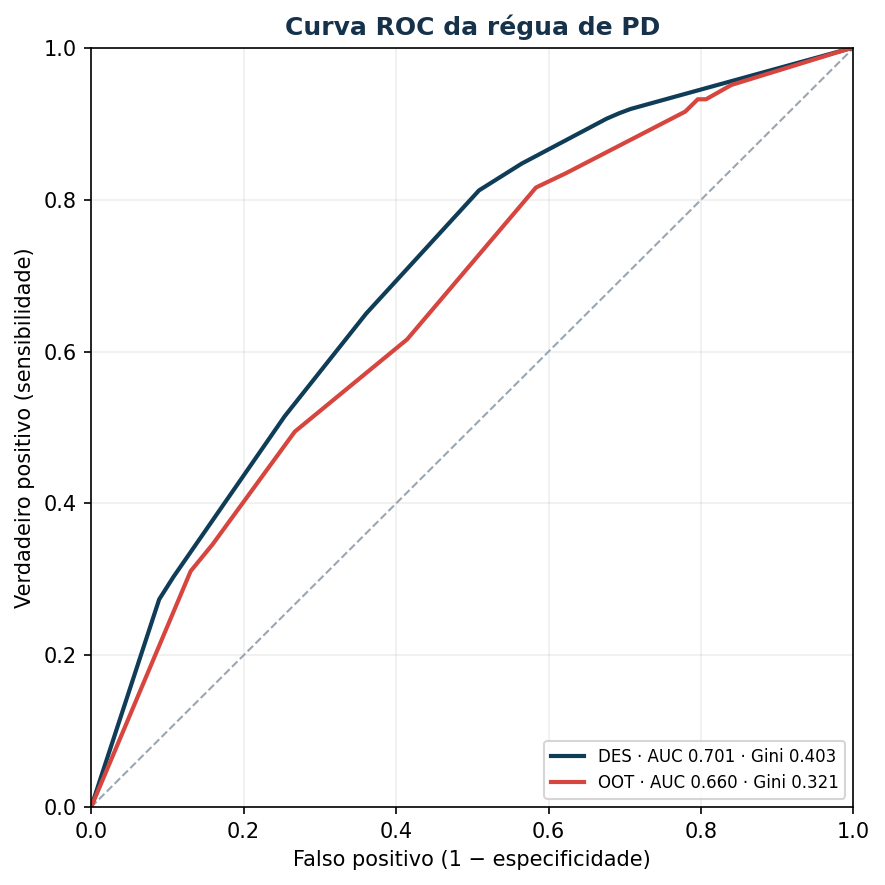

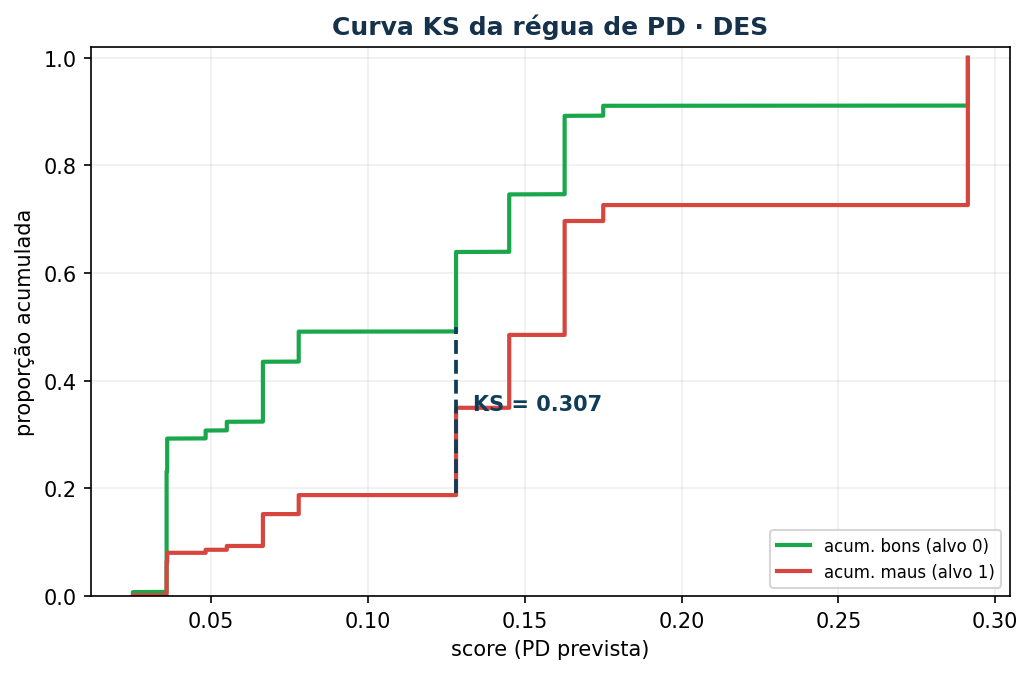

In [5]:
display(seg.metrics())
display(seg.plot_roc())   # uma curva por amostra, AUC e Gini na legenda
display(seg.plot_ks())    # acumuladas de bons × maus pelo score (DES), distância KS marcada

## Qual variável separa melhor? (IV binário)
Para PD o IV é o WoE clássico (escala de Siddiqi). Na raiz, o ranking de IV por variável, com o PSI calculado nos **mesmos bins** do IV.

In [6]:
seg.variable_iv('root')[['variavel', 'tipo', 'n_bins', 'iv', 'forca', 'pior_psi', 'psi_classificacao']]

,variavel,tipo,n_bins,iv,forca,pior_psi,psi_classificacao
0,tipo_garantia,cat,4,0.2772,médio,0.0012,estável
1,comprometimento_renda,num,5,0.2133,médio,0.4674,instável
2,score_bureau,num,6,0.1962,médio,0.0046,estável
3,meses_relacionamento,num,5,0.0517,fraco,0.0050,estável


## Análise de variáveis ao longo do tempo (safra `dt_ref`)
Com `date_col='dt_ref'`, as análises temporais já sabem a coluna de safra. Variável **numérica** (comprometimento de renda): perfil, **IV**, **PSI atual** e **PSI por safra** vs DES. Variável **categórica** (garantia): **representatividade (%) por categoria por safra**.

In [7]:
s = seg.variable_summary('comprometimento_renda')
print(f"comprometimento — média {s['media']:.3f} · mediana {s['mediana']:.3f} · desvio {s['desvio']:.3f} "
      f"· %missing {s['pct_missing']:.1f}% · IV {s['iv']:.4f} ({s['forca']})")
print("PSI atual por amostra:", {a: round(v, 3) for a, v in s['psi'].items()})
display(seg.variable_psi_by_safra('comprometimento_renda').tail(6))   # PSI por safra vs DES
display(seg.variable_share_by_safra('tipo_garantia').tail(6))         # % de cada categoria por mês

comprometimento — média 0.483 · mediana 0.478 · desvio 0.155 · %missing 0.0% · IV 0.2133 (médio)
PSI atual por amostra: {'OOT': 0.243, 'ESTABILIDADE': 0.467}


,safra,n,psi,classificacao
24,2024-07,175,0.9723,instável
25,2024-08,160,1.0544,instável
26,2024-09,150,1.1748,instável
27,2024-10,139,1.1236,instável
28,2024-11,159,1.0118,instável
29,2024-12,153,1.2819,instável


tipo_garantia,safra,alienacao,aval,fianca,sem garantia
24,2024-07,50.9,20.0,18.9,10.3
25,2024-08,53.8,22.5,18.1,5.6
26,2024-09,51.3,18.7,20.7,9.3
27,2024-10,50.4,17.3,19.4,12.9
28,2024-11,50.9,23.3,17.6,8.2
29,2024-12,47.7,20.9,19.6,11.8


## Árvore em texto e taxa de default por folha

TODA A CARTEIRA  (n=10300, 100.0%, PD=0.1269)
├─ garantia em {alienacao}  (n=5155, 50.0%, PD=0.0758)
│  ├─ comprometimento de renda até 0.5007  (n=2409, 23.4%, PD=0.0466)
│  │  ├─ score de bureau faltante  (n=121, 1.2%, PD=0.0377)  [nota 4]
│  │  ├─ score de bureau acima de 564.4  (n=1817, 17.6%, PD=0.0391)  [nota 2]
│  │  └─ score de bureau até 564.4  (n=471, 4.6%, PD=0.0777)  [nota 7]
│  └─ comprometimento de renda acima de 0.5007  (n=2746, 26.7%, PD=0.1043)
│     ├─ score de bureau acima de 640.3  (n=1267, 12.3%, PD=0.0724)  [nota 6]
│     ├─ score de bureau faltante  (n=169, 1.6%, PD=0.0833)  [nota 5]
│     └─ score de bureau até 640.3  (n=1310, 12.7%, PD=0.1381)  [nota 9]
└─ garantia em {aval ou fianca ou sem garantia}  (n=5145, 50.0%, PD=0.1781)
   ├─ score de bureau acima de 655.9  (n=2081, 20.2%, PD=0.1193)
   │  ├─ comprometimento de renda até 0.3753  (n=446, 4.3%, PD=0.0461)  [nota 3]
   │  └─ comprometimento de renda acima de 0.3753  (n=1635, 15.9%, PD=0.1419)  [nota 8]
   ├

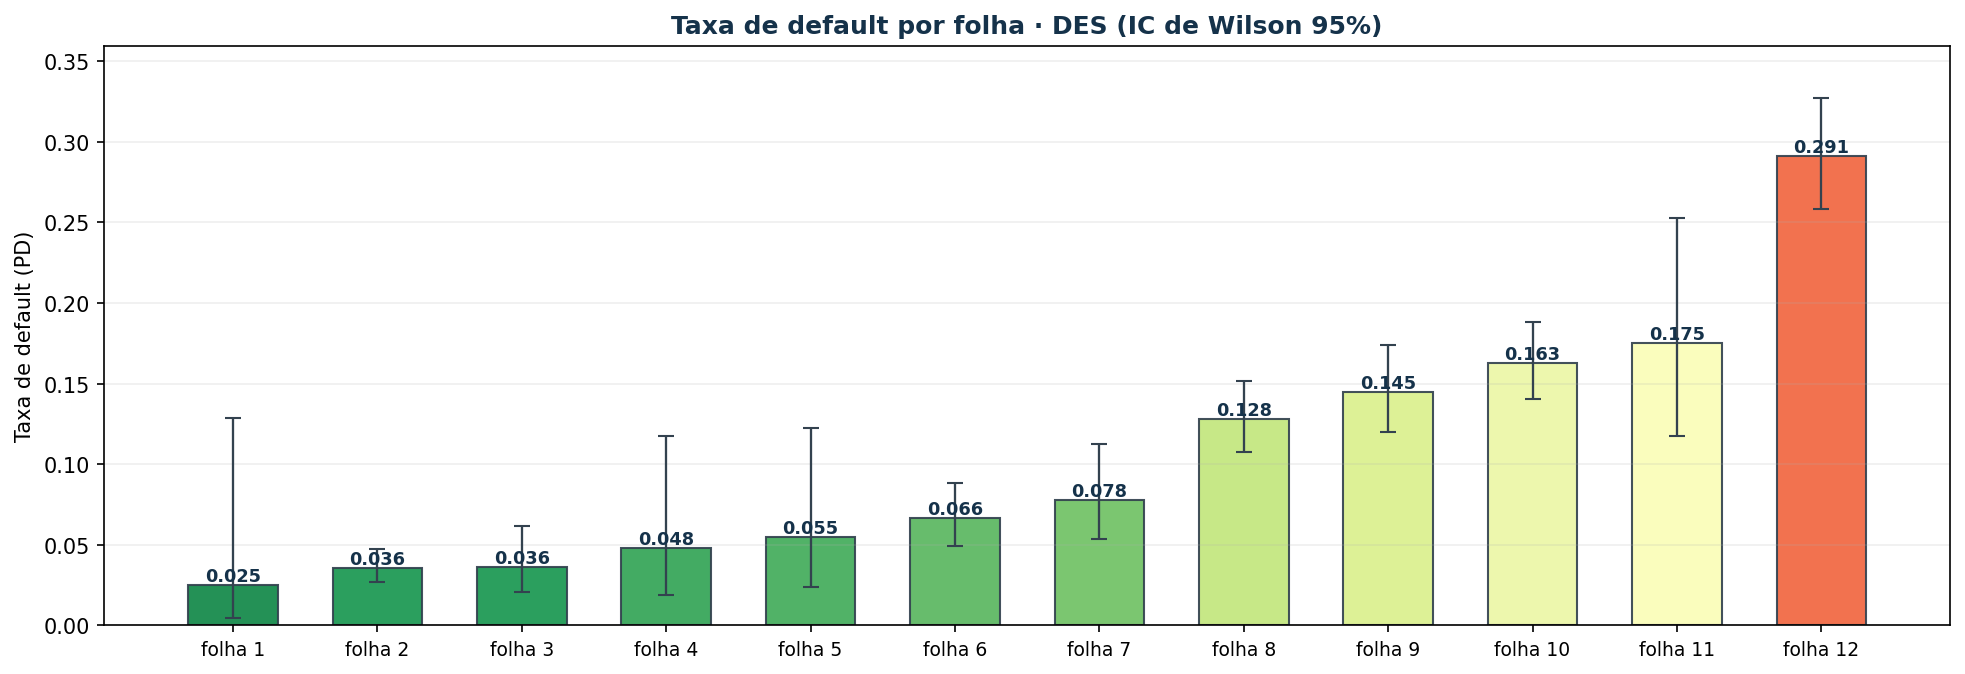

In [8]:
print(seg.tree())
display(seg.plot_leaf_badrate())   # PD por folha com IC de Wilson

## Aplicar a régua em pandas (`predict`)
Linhas com `score_bureau` faltante são roteadas para o segmento `(faltante)` — nada é descartado. `pd_regua` é a PD calibrada do segmento.

In [9]:
novos = gera(800).drop(columns=['target'])
pred = seg.predict(novos)
print('cobertura (linhas roteadas):', pred['segmento_pd'].notna().mean())
pred.head()

cobertura (linhas roteadas): 1.0


,segmento_pd,nota_pd,pd_regua
0,"tipo_garantia: {aval, fianca, sem garantia} | ...",8,0.128062
1,tipo_garantia: {alienacao} | comprometimento_r...,2,0.035743
2,"tipo_garantia: {aval, fianca, sem garantia} | ...",8,0.128062
3,"tipo_garantia: {aval, fianca, sem garantia} | ...",10,0.162690
4,tipo_garantia: {alienacao} | comprometimento_r...,7,0.077882


## Régua em PySpark (scoring em escala no Databricks)

In [10]:
print(seg.to_pyspark())

from pyspark.sql import functions as F

def aplicar_regua_pd(df, col_seg='segmento_pd', col_nota='nota_pd', col_pd='pd_regua'):
    """Régua de PD gerada por SequentialPDSegmenter (segmento, nota e PD por folha)."""
    c1 = F.col("tipo_garantia").cast("string").isin('aval', 'fianca', 'sem garantia') & F.col("score_bureau").isNull() & (F.col("comprometimento_renda") <= 0.369095042347908)
    c2 = F.col("tipo_garantia").cast("string").isin('alienacao') & (F.col("comprometimento_renda") <= 0.5006638765335083) & (F.col("score_bureau") > 564.4178771972656)
    c3 = F.col("tipo_garantia").cast("string").isin('aval', 'fianca', 'sem garantia') & (F.col("score_bureau") > 655.9372863769531) & (F.col("comprometimento_renda") <= 0.3752504140138626)
    c4 = F.col("tipo_garantia").cast("string").isin('alienacao') & (F.col("comprometimento_renda") <= 0.5006638765335083) & F.col("score_bureau").isNull()
    c5 = F.col("tipo_garantia").cast("string").isin('alienacao') & (F.col("comprometimento_renda"

## Interface interativa — workbench em abas (opcional)

No Jupyter/Databricks dá para construir e validar a árvore clicando, com **KS e AUC ao vivo** na faixa de KPIs. As 5 abas:

- **① Construir** — IV/PSI por variável, árvore, preview, criar/fundir/recolher folha, auto-fit, auto-fundir, podar, desfazer/refazer.
- **② Análise de variável** — distribuição, %missing, estatísticas, PSI atual e por safra (numérica → percentis; categórica → representatividade por safra).
- **③ Diagnóstico** — folhas (PSI e teste de hipótese), **curvas ROC e KS**, métricas (KS/AUC/Gini/Acurácia/F1), IC bootstrap, taxa de default e distribuição do score.
- **④ Validar & Exportar** — monotonicidade, calibração, backtest, exportar `ui.result`, MLflow e Spark.
- **⑤ Histórico** — salvar/carregar a árvore em JSON e a imagem da árvore.

```python
from yggdrasil.credit_risk.pd import PDSegmenterUI
ui = PDSegmenterUI(df, target='target', sample_col='amostra', ref_sample='DES',
                   date_col='dt_ref',
                   feature_labels={'comprometimento_renda': 'comprometimento de renda',
                                   'score_bureau': 'score de bureau', 'tipo_garantia': 'garantia'},
                   tree_samples=['DES', 'OOT'])   # PD na árvore (ESTABILIDADE só no PSI)
ui
```

## Registrar no MLflow / Unity Catalog
```python
seg.log_to_mlflow(registered_model_name='catalogo.schema.pd_segmentacao',
                  registry_uri='databricks-uc')
```